In [1]:
# ============================================================
# 02_mobilenetv2_baseline_training.ipynb
# Cell 1: Drive Mount, GPU Check, Path Setup
# ============================================================

import os
import zipfile
from pathlib import Path

import torch
import pandas as pd
from google.colab import drive

# -----------------------------
# 1. Mount Google Drive
# -----------------------------
drive.mount("/content/drive")

# -----------------------------
# 2. GPU / runtime check
# -----------------------------
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU is not available. Please enable GPU before training.")
    device = torch.device("cpu")

print("Using device:", device)

# Stop training if GPU is not available
if device.type != "cuda":
    raise RuntimeError("GPU is not available. Please enable GPU in Colab before starting baseline training.")

# -----------------------------
# 3. Define project paths
# -----------------------------
PROJECT_ROOT = Path("/content/drive/MyDrive/Thesis/thesis_project")

ZIP_PATH = Path("/content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip")

LOCAL_DATA_ROOT = Path("/content/data")
DATASET_PATH = LOCAL_DATA_ROOT / "PlantVillage"

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_CSV = DATA_DIR / "train_files.csv"
VAL_CSV = DATA_DIR / "val_files.csv"
TEST_CSV = DATA_DIR / "test_files.csv"
LABEL_MAP_CSV = DATA_DIR / "label_map.csv"

BASELINE_DIR = PROJECT_ROOT / "01_baseline_before_optimization"
BASELINE_MODEL_DIR = BASELINE_DIR / "models"
BASELINE_RESULT_DIR = BASELINE_DIR / "results"

BASELINE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("\nProject root:", PROJECT_ROOT)
print("Dataset zip:", ZIP_PATH)
print("Local dataset path:", DATASET_PATH)
print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VAL_CSV)
print("Test CSV:", TEST_CSV)
print("Label map CSV:", LABEL_MAP_CSV)
print("Baseline model directory:", BASELINE_MODEL_DIR)
print("Baseline result directory:", BASELINE_RESULT_DIR)

Mounted at /content/drive
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU name: Tesla T4
Using device: cuda

Project root: /content/drive/MyDrive/Thesis/thesis_project
Dataset zip: /content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Local dataset path: /content/data/PlantVillage
Train CSV: /content/drive/MyDrive/Thesis/thesis_project/data/train_files.csv
Validation CSV: /content/drive/MyDrive/Thesis/thesis_project/data/val_files.csv
Test CSV: /content/drive/MyDrive/Thesis/thesis_project/data/test_files.csv
Label map CSV: /content/drive/MyDrive/Thesis/thesis_project/data/label_map.csv
Baseline model directory: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models
Baseline result directory: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results


In [2]:
# ============================================================
# Cell 2: Dataset Extraction and CSV Verification
# ============================================================

# -----------------------------
# 1. Check dataset zip
# -----------------------------
if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset zip file not found: {ZIP_PATH}")

print("Dataset zip found:", ZIP_PATH)

# -----------------------------
# 2. Extract dataset if needed
# -----------------------------
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)

if not DATASET_PATH.exists():
    print("Unzipping dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATA_ROOT)
    print("Unzip complete.")
else:
    print("Dataset already extracted in Colab runtime.")

print("Dataset exists:", DATASET_PATH.exists())
print("Dataset path:", DATASET_PATH)

# -----------------------------
# 3. Verify split CSV files
# -----------------------------
required_csv_files = [TRAIN_CSV, VAL_CSV, TEST_CSV, LABEL_MAP_CSV]

print("\nCSV file check:")
for file_path in required_csv_files:
    print(file_path.name, "exists:", file_path.exists())

for file_path in required_csv_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Required CSV file missing: {file_path}")

# -----------------------------
# 4. Load CSV files
# -----------------------------
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)
label_map_df = pd.read_csv(LABEL_MAP_CSV)

num_classes = len(label_map_df)

print("\nLoaded split files successfully.")
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))
print("Number of classes:", num_classes)

display(label_map_df.head())

Dataset zip found: /content/drive/MyDrive/Thesis/Dataset/PlantVillage.zip
Unzipping dataset...
Unzip complete.
Dataset exists: True
Dataset path: /content/data/PlantVillage

CSV file check:
train_files.csv exists: True
val_files.csv exists: True
test_files.csv exists: True
label_map.csv exists: True

Loaded split files successfully.
Train images: 40728
Validation images: 8146
Test images: 5431
Number of classes: 38


,class_name,label
0,Apple___Apple_scab,0
1,Apple___Black_rot,1
2,Apple___Cedar_apple_rust,2
3,Apple___healthy,3
4,Blueberry___healthy,4


In [3]:
# ============================================================
# Cell 3: Imports and Training Configuration
# ============================================================

import time
import copy
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import MobileNet_V2_Weights

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# -----------------------------
# 1. Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Faster GPU performance for fixed input size
torch.backends.cudnn.benchmark = True

# -----------------------------
# 2. Training configuration
# -----------------------------
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 2

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Number of classes:", num_classes)
print("Device:", device)

Image size: 224
Batch size: 32
Epochs: 10
Learning rate: 0.0001
Number of classes: 38
Device: cuda


In [4]:
# ============================================================
# Cell 4: Dataset Class and Image Transform
# ============================================================

class PlantVillageDataset(Dataset):
    def __init__(self, dataframe, dataset_root, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = self.dataset_root / row["relative_path"]
        label = int(row["label"])

        # Important: convert all images to RGB
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# -----------------------------
# 1. ImageNet normalization values
# -----------------------------
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# -----------------------------
# 2. Training transform
# -----------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# -----------------------------
# 3. Validation transform
# -----------------------------
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# -----------------------------
# 4. Create train and validation datasets
# -----------------------------
train_dataset = PlantVillageDataset(
    dataframe=train_df,
    dataset_root=DATASET_PATH,
    transform=train_transform
)

val_dataset = PlantVillageDataset(
    dataframe=val_df,
    dataset_root=DATASET_PATH,
    transform=val_transform
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

# -----------------------------
# 5. Check one sample
# -----------------------------
sample_image, sample_label = train_dataset[0]

print("Sample image tensor shape:", sample_image.shape)
print("Sample label:", sample_label)
print("Sample image dtype:", sample_image.dtype)

Train dataset size: 40728
Validation dataset size: 8146
Sample image tensor shape: torch.Size([3, 224, 224])
Sample label: 35
Sample image dtype: torch.float32


In [5]:
# ============================================================
# Cell 5: DataLoader Creation and Batch Check
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

# -----------------------------
# Check one batch
# -----------------------------
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("Batch image dtype:", images.dtype)
print("Batch label dtype:", labels.dtype)

Train batches: 1273
Validation batches: 255
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Batch image dtype: torch.float32
Batch label dtype: torch.int64


In [6]:
# ============================================================
# Cell 6: Create MobileNetV2 Baseline Model
# ============================================================

# -----------------------------
# 1. Load pretrained MobileNetV2
# -----------------------------
weights = MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# -----------------------------
# 2. Replace final classifier for 38 classes
# -----------------------------
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

# -----------------------------
# 3. Move model to GPU
# -----------------------------
model = model.to(device)

# -----------------------------
# 4. Define loss function
# -----------------------------
criterion = nn.CrossEntropyLoss()

# -----------------------------
# 5. Define optimizer
# -----------------------------
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# -----------------------------
# 6. Learning rate scheduler
# -----------------------------
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# -----------------------------
# 7. Count parameters
# -----------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("MobileNetV2 baseline model created successfully.")
print("Input features of classifier:", in_features)
print("Number of output classes:", num_classes)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Model device:", next(model.parameters()).device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 136MB/s]

MobileNetV2 baseline model created successfully.
Input features of classifier: 1280
Number of output classes: 38
Total parameters: 2272550
Trainable parameters: 2272550
Model device: cuda:0


In [9]:
# ============================================================
# Cell 6.1: Check MobileNetV2 Architecture
# ============================================================

print(model)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [7]:
# ============================================================
# Cell 7: Training and Validation Functions
# ============================================================

from tqdm import tqdm

# Mixed precision training helps GPU training run faster and use less memory
USE_AMP = True if device.type == "cuda" else False
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print("Mixed precision enabled:", USE_AMP)


def train_one_epoch(model, dataloader, criterion, optimizer, device, scaler=None):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        if scaler is not None and USE_AMP:
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        progress_bar.set_postfix({
            "loss": loss.item()
        })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_accuracy


def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(dataloader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

            progress_bar.set_postfix({
                "loss": loss.item()
            })

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, precision, recall, f1

Mixed precision enabled: True


In [8]:
# ============================================================
# Cell 8: Checkpoint and Resume System
# ============================================================

# -----------------------------
# 1. Define checkpoint paths
# -----------------------------
LAST_CHECKPOINT_PATH = BASELINE_MODEL_DIR / "mobilenetv2_baseline_last_checkpoint.pth"
BEST_MODEL_PATH = BASELINE_MODEL_DIR / "mobilenetv2_baseline_best.pth"
FINAL_MODEL_PATH = BASELINE_MODEL_DIR / "mobilenetv2_baseline_final.pth"

HISTORY_CSV_PATH = BASELINE_RESULT_DIR / "baseline_training_history.csv"

print("Last checkpoint path:", LAST_CHECKPOINT_PATH)
print("Best model path:", BEST_MODEL_PATH)
print("Final model path:", FINAL_MODEL_PATH)
print("History CSV path:", HISTORY_CSV_PATH)


# -----------------------------
# 2. Save checkpoint function
# -----------------------------
def save_checkpoint(
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    best_val_accuracy,
    training_history,
    is_best=False
):
    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "best_val_accuracy": best_val_accuracy,
        "training_history": training_history,
        "num_classes": num_classes,
        "image_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "model_name": "MobileNetV2",
    }

    # Save last checkpoint
    torch.save(checkpoint, LAST_CHECKPOINT_PATH)

    # Save epoch-wise checkpoint
    epoch_checkpoint_path = BASELINE_MODEL_DIR / f"mobilenetv2_baseline_epoch_{epoch}.pth"
    torch.save(checkpoint, epoch_checkpoint_path)

    # Save best model checkpoint
    if is_best:
        torch.save(checkpoint, BEST_MODEL_PATH)

    # Save training history CSV
    history_df = pd.DataFrame(training_history)
    history_df.to_csv(HISTORY_CSV_PATH, index=False)

    print(f"Checkpoint saved for epoch {epoch}")

    if is_best:
        print(f"Best model updated at epoch {epoch}")


# -----------------------------
# 3. Load checkpoint function
# -----------------------------
def load_checkpoint_if_available(resume=True):
    if resume and LAST_CHECKPOINT_PATH.exists():
        print("Existing checkpoint found. Loading checkpoint...")

        checkpoint = torch.load(
            LAST_CHECKPOINT_PATH,
            map_location=device,
            weights_only=False
        )

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        if scheduler is not None and checkpoint.get("scheduler_state_dict") is not None:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

        if scaler is not None and checkpoint.get("scaler_state_dict") is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])

        start_epoch = checkpoint["epoch"] + 1
        best_val_accuracy = checkpoint.get("best_val_accuracy", 0.0)
        training_history = checkpoint.get("training_history", [])

        print(f"Resuming training from epoch {start_epoch}")
        print(f"Best validation accuracy so far: {best_val_accuracy:.4f}")

    else:
        print("No checkpoint loaded. Starting training from scratch.")

        start_epoch = 1
        best_val_accuracy = 0.0
        training_history = []

    return start_epoch, best_val_accuracy, training_history


# -----------------------------
# 4. Resume setting
# -----------------------------
RESUME_TRAINING = True

start_epoch, best_val_accuracy, training_history = load_checkpoint_if_available(
    resume=RESUME_TRAINING
)

print("\nStart epoch:", start_epoch)
print("Best validation accuracy:", best_val_accuracy)
print("History records:", len(training_history))

Last checkpoint path: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_last_checkpoint.pth
Best model path: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_best.pth
Final model path: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_final.pth
History CSV path: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_training_history.csv
No checkpoint loaded. Starting training from scratch.

Start epoch: 1
Best validation accuracy: 0.0
History records: 0


In [10]:
# ============================================================
# Cell 9: Baseline MobileNetV2 Training Loop
# ============================================================

print("Starting baseline training...")
print("Training will run from epoch", start_epoch, "to", NUM_EPOCHS)
print("Best validation accuracy before training:", best_val_accuracy)

training_start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    epoch_start_time = time.time()

    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 50)

    # -----------------------------
    # 1. Training
    # -----------------------------
    train_loss, train_accuracy = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        scaler=scaler
    )

    # -----------------------------
    # 2. Validation
    # -----------------------------
    val_loss, val_accuracy, val_precision, val_recall, val_f1 = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device
    )

    # -----------------------------
    # 3. Scheduler step
    # -----------------------------
    scheduler.step(val_accuracy)

    # -----------------------------
    # 4. Epoch time
    # -----------------------------
    epoch_time = time.time() - epoch_start_time
    current_lr = optimizer.param_groups[0]["lr"]

    # -----------------------------
    # 5. Check if best model
    # -----------------------------
    is_best = val_accuracy > best_val_accuracy

    if is_best:
        best_val_accuracy = val_accuracy

    # -----------------------------
    # 6. Save history
    # -----------------------------
    epoch_record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_accuracy,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy,
        "val_precision_macro": val_precision,
        "val_recall_macro": val_recall,
        "val_f1_macro": val_f1,
        "learning_rate": current_lr,
        "epoch_time_seconds": epoch_time,
        "is_best": is_best
    }

    training_history.append(epoch_record)

    # -----------------------------
    # 7. Print epoch result
    # -----------------------------
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Precision Macro: {val_precision:.4f}")
    print(f"Validation Recall Macro: {val_recall:.4f}")
    print(f"Validation F1 Macro: {val_f1:.4f}")

    print(f"Learning Rate: {current_lr}")
    print(f"Epoch Time: {epoch_time / 60:.2f} minutes")

    if is_best:
        print("This is the best model so far.")

    # -----------------------------
    # 8. Save checkpoint
    # -----------------------------
    save_checkpoint(
        epoch=epoch,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        best_val_accuracy=best_val_accuracy,
        training_history=training_history,
        is_best=is_best
    )

# -----------------------------
# 9. Save final model checkpoint
# -----------------------------
final_checkpoint = {
    "epoch": NUM_EPOCHS,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
    "best_val_accuracy": best_val_accuracy,
    "training_history": training_history,
    "num_classes": num_classes,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "model_name": "MobileNetV2"
}

torch.save(final_checkpoint, FINAL_MODEL_PATH)

# Save final history again
history_df = pd.DataFrame(training_history)
history_df.to_csv(HISTORY_CSV_PATH, index=False)

total_training_time = time.time() - training_start_time

print("\nTraining completed.")
print("Best validation accuracy:", best_val_accuracy)
print("Total training time:", total_training_time / 60, "minutes")
print("Best model saved at:", BEST_MODEL_PATH)
print("Final model saved at:", FINAL_MODEL_PATH)
print("Training history saved at:", HISTORY_CSV_PATH)

Starting baseline training...
Training will run from epoch 1 to 10
Best validation accuracy before training: 0.0

Epoch 1/10
--------------------------------------------------


Train Loss: 0.4862
Train Accuracy: 0.8901
Validation Loss: 0.0506
Validation Accuracy: 0.9854
Validation Precision Macro: 0.9802
Validation Recall Macro: 0.9791
Validation F1 Macro: 0.9788
Learning Rate: 0.0001
Epoch Time: 4.23 minutes
This is the best model so far.
Checkpoint saved for epoch 1
Best model updated at epoch 1

Epoch 2/10
--------------------------------------------------


Train Loss: 0.0580
Train Accuracy: 0.9846
Validation Loss: 0.0244
Validation Accuracy: 0.9930
Validation Precision Macro: 0.9901
Validation Recall Macro: 0.9906
Validation F1 Macro: 0.9902
Learning Rate: 0.0001
Epoch Time: 3.06 minutes
This is the best model so far.
Checkpoint saved for epoch 2
Best model updated at epoch 2

Epoch 3/10
--------------------------------------------------


Train Loss: 0.0340
Train Accuracy: 0.9907
Validation Loss: 0.0206
Validation Accuracy: 0.9936
Validation Precision Macro: 0.9908
Validation Recall Macro: 0.9903
Validation F1 Macro: 0.9904
Learning Rate: 0.0001
Epoch Time: 3.05 minutes
This is the best model so far.
Checkpoint saved for epoch 3
Best model updated at epoch 3

Epoch 4/10
--------------------------------------------------


Train Loss: 0.0230
Train Accuracy: 0.9934
Validation Loss: 0.0202
Validation Accuracy: 0.9940
Validation Precision Macro: 0.9931
Validation Recall Macro: 0.9910
Validation F1 Macro: 0.9920
Learning Rate: 0.0001
Epoch Time: 3.05 minutes
This is the best model so far.
Checkpoint saved for epoch 4
Best model updated at epoch 4

Epoch 5/10
--------------------------------------------------


...

Train Loss: 0.0169
Train Accuracy: 0.9951
Validation Loss: 0.0192
Validation Accuracy: 0.9934
Validation Precision Macro: 0.9910
Validation Recall Macro: 0.9897
Validation F1 Macro: 0.9902
Learning Rate: 0.0001
Epoch Time: 3.09 minutes
Checkpoint saved for epoch 6

Epoch 7/10
--------------------------------------------------


Train Loss: 0.0134
Train Accuracy: 0.9962
Validation Loss: 0.0133
Validation Accuracy: 0.9959
Validation Precision Macro: 0.9932
Validation Recall Macro: 0.9941
Validation F1 Macro: 0.9936
Learning Rate: 0.0001
Epoch Time: 3.05 minutes
This is the best model so far.
Checkpoint saved for epoch 7
Best model updated at epoch 7

Epoch 8/10
--------------------------------------------------


Train Loss: 0.0119
Train Accuracy: 0.9966
Validation Loss: 0.0117
Validation Accuracy: 0.9963
Validation Precision Macro: 0.9951
Validation Recall Macro: 0.9950
Validation F1 Macro: 0.9950
Learning Rate: 0.0001
Epoch Time: 3.07 minutes
This is the best model so far.
Checkpoint saved for epoch 8
Best model updated at epoch 8

Epoch 9/10
--------------------------------------------------


Train Loss: 0.0116
Train Accuracy: 0.9965
Validation Loss: 0.0111
Validation Accuracy: 0.9969
Validation Precision Macro: 0.9963
Validation Recall Macro: 0.9968
Validation F1 Macro: 0.9966
Learning Rate: 0.0001
Epoch Time: 3.09 minutes
This is the best model so far.
Checkpoint saved for epoch 9
Best model updated at epoch 9

Epoch 10/10
--------------------------------------------------


Train Loss: 0.0094
Train Accuracy: 0.9972
Validation Loss: 0.0150
Validation Accuracy: 0.9953
Validation Precision Macro: 0.9941
Validation Recall Macro: 0.9939
Validation F1 Macro: 0.9939
Learning Rate: 0.0001
Epoch Time: 3.07 minutes
Checkpoint saved for epoch 10

Training completed.
Best validation accuracy: 0.9969310090842131
Total training time: 31.909075295925142 minutes
Best model saved at: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_best.pth
Final model saved at: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/models/mobilenetv2_baseline_final.pth
Training history saved at: /content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_training_history.csv


In [11]:
# ============================================================
# Cell 10: Training History Check
# ============================================================

history_df = pd.read_csv(HISTORY_CSV_PATH)

print("Training history loaded successfully.")
print("Total records:", len(history_df))

display(history_df)

best_row = history_df.loc[history_df["val_accuracy"].idxmax()]

print("\nBest epoch summary:")
print("Best epoch:", int(best_row["epoch"]))
print("Best validation accuracy:", best_row["val_accuracy"])
print("Best validation F1 macro:", best_row["val_f1_macro"])
print("Best validation loss:", best_row["val_loss"])
print("Training accuracy at best epoch:", best_row["train_accuracy"])
print("Training loss at best epoch:", best_row["train_loss"])

Training history loaded successfully.
Total records: 10


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,learning_rate,epoch_time_seconds,is_best
0,1,0.486151,0.890051,0.050605,0.985392,0.980226,0.979094,0.978777,0.0001,253.687426,True
1,2,0.058043,0.984581,0.024436,0.993003,0.990126,0.990589,0.990177,0.0001,183.622371,True
2,3,0.033962,0.990694,0.020648,0.993616,0.990751,0.990284,0.990428,0.0001,183.268825,True
3,4,0.023011,0.993444,0.020153,0.993985,0.993142,0.991009,0.991972,0.0001,182.872638,True
4,5,0.018550,0.994647,0.015447,0.995581,0.993503,0.993028,0.993215,0.0001,183.248045,True
5,6,0.016950,0.995089,0.019213,0.993371,0.990967,0.989723,0.990160,0.0001,185.305176,False
6,7,0.013415,0.996219,0.013328,0.995949,0.993235,0.994076,0.993556,0.0001,182.903681,True
7,8,0.011892,0.996636,0.011718,0.996317,0.995070,0.994981,0.994995,0.0001,183.902530,True
8,9,0.011571,0.996464,0.011101,0.996931,0.996324,0.996799,0.996551,0.0001,185.142356,True
9,10,0.009363,0.997201,0.015001,0.995335,0.994138,0.993919,0.993940,0.0001,184.153300,False



Best epoch summary:
Best epoch: 9
Best validation accuracy: 0.9969310090842132
Best validation F1 macro: 0.996551361724906
Best validation loss: 0.0111013860893343
Training accuracy at best epoch: 0.9964643488509134
Training loss at best epoch: 0.0115708169294841


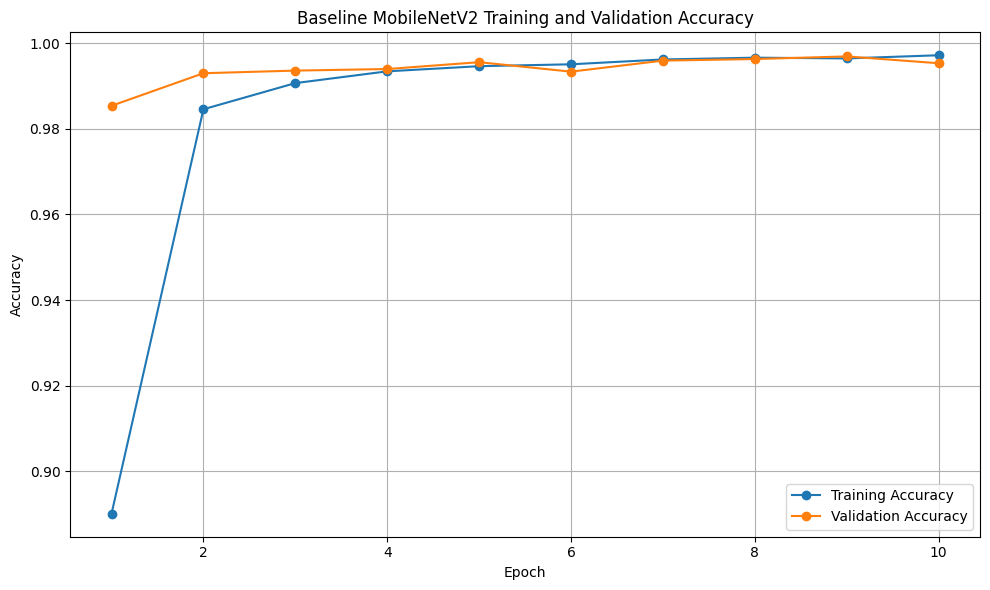

Accuracy curve saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_accuracy_curve.png


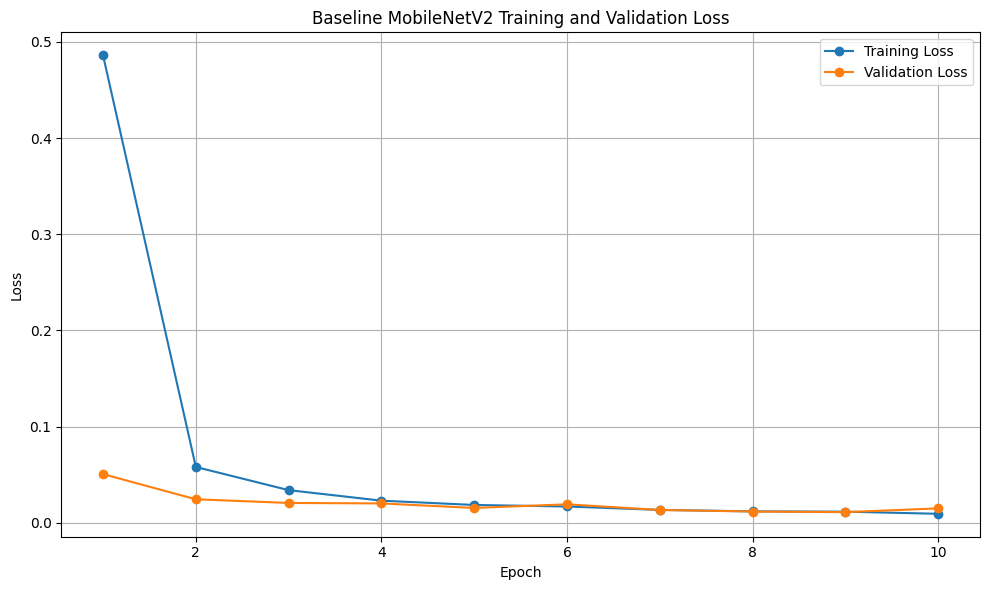

Loss curve saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_loss_curve.png


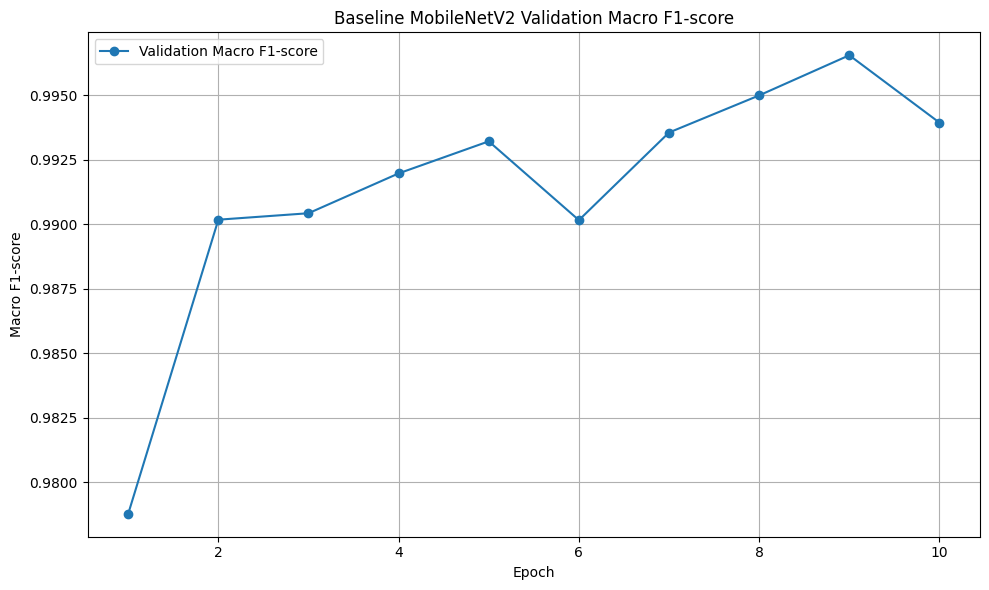

Validation F1 curve saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_val_f1_curve.png


In [12]:
# ============================================================
# Cell 11: Training Curve Plot
# ============================================================

import matplotlib.pyplot as plt

# -----------------------------
# 1. Accuracy curve
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_accuracy"], marker="o", label="Training Accuracy")
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline MobileNetV2 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()

accuracy_curve_path = BASELINE_RESULT_DIR / "baseline_accuracy_curve.png"
plt.savefig(accuracy_curve_path, dpi=300)
plt.show()

print("Accuracy curve saved at:")
print(accuracy_curve_path)

# -----------------------------
# 2. Loss curve
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Training Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline MobileNetV2 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

loss_curve_path = BASELINE_RESULT_DIR / "baseline_loss_curve.png"
plt.savefig(loss_curve_path, dpi=300)
plt.show()

print("Loss curve saved at:")
print(loss_curve_path)

# -----------------------------
# 3. Validation F1-score curve
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="Validation Macro F1-score")
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Baseline MobileNetV2 Validation Macro F1-score")
plt.legend()
plt.grid(True)
plt.tight_layout()

f1_curve_path = BASELINE_RESULT_DIR / "baseline_val_f1_curve.png"
plt.savefig(f1_curve_path, dpi=300)
plt.show()

print("Validation F1 curve saved at:")
print(f1_curve_path)

In [13]:
# ============================================================
# Cell 12: Best Model and Output File Verification
# ============================================================

required_output_files = [
    BASELINE_MODEL_DIR / "mobilenetv2_baseline_best.pth",
    BASELINE_MODEL_DIR / "mobilenetv2_baseline_final.pth",
    BASELINE_MODEL_DIR / "mobilenetv2_baseline_last_checkpoint.pth",
    BASELINE_RESULT_DIR / "baseline_training_history.csv",
    BASELINE_RESULT_DIR / "baseline_accuracy_curve.png",
    BASELINE_RESULT_DIR / "baseline_loss_curve.png",
    BASELINE_RESULT_DIR / "baseline_val_f1_curve.png",
]

print("Baseline training output verification:\n")

all_files_ok = True

for file_path in required_output_files:
    exists = file_path.exists()
    print(file_path.name, "->", exists)

    if not exists:
        all_files_ok = False

print("\nModel folder files:")
for item in sorted(BASELINE_MODEL_DIR.iterdir()):
    print(item.name)

print("\nResults folder files:")
for item in sorted(BASELINE_RESULT_DIR.iterdir()):
    print(item.name)

if all_files_ok:
    print("\nAll required baseline training outputs are available.")
else:
    print("\nSome required files are missing. Please check the output above.")

Baseline training output verification:

mobilenetv2_baseline_best.pth -> True
mobilenetv2_baseline_final.pth -> True
mobilenetv2_baseline_last_checkpoint.pth -> True
baseline_training_history.csv -> True
baseline_accuracy_curve.png -> True
baseline_loss_curve.png -> True
baseline_val_f1_curve.png -> True

Model folder files:
mobilenetv2_baseline_best.pth
mobilenetv2_baseline_epoch_1.pth
mobilenetv2_baseline_epoch_10.pth
mobilenetv2_baseline_epoch_2.pth
mobilenetv2_baseline_epoch_3.pth
mobilenetv2_baseline_epoch_4.pth
mobilenetv2_baseline_epoch_5.pth
mobilenetv2_baseline_epoch_6.pth
mobilenetv2_baseline_epoch_7.pth
mobilenetv2_baseline_epoch_8.pth
mobilenetv2_baseline_epoch_9.pth
mobilenetv2_baseline_final.pth
mobilenetv2_baseline_last_checkpoint.pth

Results folder files:
baseline_accuracy_curve.png
baseline_loss_curve.png
baseline_training_history.csv
baseline_val_f1_curve.png

All required baseline training outputs are available.


In [14]:
# ============================================================
# Cell 13: Best Model Reload and Quick Validation Check
# ============================================================

# -----------------------------
# 1. Create a fresh MobileNetV2 architecture
# -----------------------------
best_model = models.mobilenet_v2(weights=None)

in_features = best_model.classifier[1].in_features
best_model.classifier[1] = nn.Linear(in_features, num_classes)

# -----------------------------
# 2. Load best checkpoint
# -----------------------------
best_checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

best_model.load_state_dict(best_checkpoint["model_state_dict"])
best_model = best_model.to(device)
best_model.eval()

print("Best model loaded successfully.")
print("Best checkpoint epoch:", best_checkpoint["epoch"])
print("Best checkpoint validation accuracy:", best_checkpoint["best_val_accuracy"])
print("Model device:", next(best_model.parameters()).device)

# -----------------------------
# 3. Validate loaded best model
# -----------------------------
best_val_loss, best_val_accuracy, best_val_precision, best_val_recall, best_val_f1 = validate_one_epoch(
    model=best_model,
    dataloader=val_loader,
    criterion=criterion,
    device=device
)

print("\nReloaded best model validation result:")
print("Validation Loss:", best_val_loss)
print("Validation Accuracy:", best_val_accuracy)
print("Validation Precision Macro:", best_val_precision)
print("Validation Recall Macro:", best_val_recall)
print("Validation F1 Macro:", best_val_f1)

Best model loaded successfully.
Best checkpoint epoch: 9
Best checkpoint validation accuracy: 0.9969310090842131
Model device: cuda:0



Reloaded best model validation result:
Validation Loss: 0.011101386089334317
Validation Accuracy: 0.9969310090842131
Validation Precision Macro: 0.996324167721049
Validation Recall Macro: 0.9967992163745207
Validation F1 Macro: 0.9965513617249061


In [15]:
# ============================================================
# Cell 14: Save Baseline Training Summary
# ============================================================

baseline_summary = {
    "model_name": "MobileNetV2 Baseline",
    "dataset": "PlantVillage",
    "num_classes": num_classes,
    "train_images": len(train_df),
    "validation_images": len(val_df),
    "test_images": len(test_df),
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "total_epochs": NUM_EPOCHS,
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_val_loss": best_val_loss,
    "best_val_accuracy": best_val_accuracy,
    "best_val_precision_macro": best_val_precision,
    "best_val_recall_macro": best_val_recall,
    "best_val_f1_macro": best_val_f1,
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "best_model_path": str(BEST_MODEL_PATH),
    "final_model_path": str(FINAL_MODEL_PATH),
    "training_history_path": str(HISTORY_CSV_PATH)
}

baseline_summary_df = pd.DataFrame([baseline_summary])

baseline_summary_path = BASELINE_RESULT_DIR / "baseline_training_summary.csv"
baseline_summary_df.to_csv(baseline_summary_path, index=False)

print("Baseline training summary saved at:")
print(baseline_summary_path)

display(baseline_summary_df)

Baseline training summary saved at:
/content/drive/MyDrive/Thesis/thesis_project/01_baseline_before_optimization/results/baseline_training_summary.csv


,model_name,dataset,num_classes,train_images,validation_images,test_images,image_size,batch_size,total_epochs,best_epoch,best_val_loss,best_val_accuracy,best_val_precision_macro,best_val_recall_macro,best_val_f1_macro,total_parameters,trainable_parameters,best_model_path,final_model_path,training_history_path
0,MobileNetV2 Baseline,PlantVillage,38,40728,8146,5431,224,32,10,9,0.011101,0.996931,0.996324,0.996799,0.996551,2272550,2272550,/content/drive/MyDrive/Thesis/thesis_project/0...,/content/drive/MyDrive/Thesis/thesis_project/0...,/content/drive/MyDrive/Thesis/thesis_project/0...
